# (노트) tf.keras.Sequential 사용방법 

### imports

In [14]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt 

In [15]:
import tensorflow.experimental.numpy as tnp 

In [16]:
tnp.experimental_enable_numpy_behavior() 

In [17]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+s + '; }')

### 예비학습: $x \to \hat{y}$ 가 되는 과정을 그림으로 그리기

`-` 단순회귀분석의 예시
- $\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i, \quad i=1,2,\dots,n$

(아주 정확한 표현) 제가 진짜 한땀한땀 만들었어요 

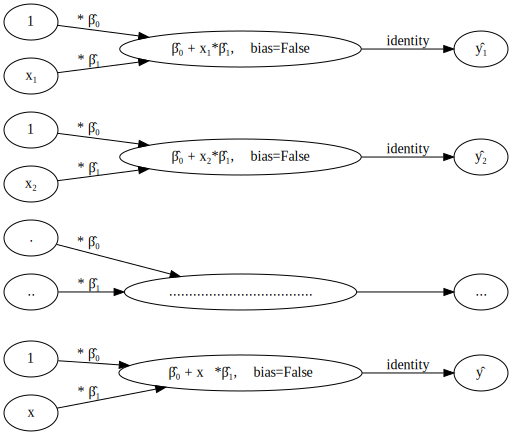

In [18]:
gv(''' 
    "1" -> "β̂₀ + xₙ*β̂₁,    bias=False"[label="* β̂₀"]
    "xₙ" -> "β̂₀ + xₙ*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + xₙ*β̂₁,    bias=False" -> "ŷₙ"[label="identity"]

    "." -> "...................................."[label="* β̂₀"]
    ".." -> "...................................."[label="* β̂₁"]
    "...................................." -> "..."[label=" "]

    "1 " -> "β̂₀ + x₂*β̂₁,    bias=False"[label="* β̂₀"]
    "x₂" -> "β̂₀ + x₂*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x₂*β̂₁,    bias=False" -> "ŷ₂"[label="identity"]
    
    "1  " -> "β̂₀ + x₁*β̂₁,    bias=False"[label="* β̂₀"]
    "x₁" -> "β̂₀ + x₁*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x₁*β̂₁,    bias=False" -> "ŷ₁"[label="identity"]
''')


`-` 감상? 
- 교수님이 고생한것 같음 
- 그런데 그냥 하나의 $x_i$에 대하여 하나만 만들고 복붙하면 되지 않나? 

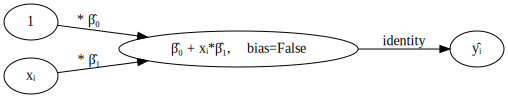

In [19]:
gv(''' 
    "1" -> "β̂₀ + xᵢ*β̂₁,    bias=False"[label="* β̂₀"]
    "xᵢ" -> "β̂₀ + xᵢ*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + xᵢ*β̂₁,    bias=False" -> "ŷᵢ"[label="identity"]

''')


`-` $i$ 역시 그냥 생략해도 될 듯. 어떠한 특정한 하나의 관측치를 가정하고 아래와 같이표현해도 ok

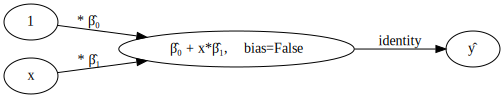

In [20]:
gv(''' 
    "1" -> "β̂₀ + x*β̂₁,    bias=False"[label="* β̂₀"]
    "x" -> "β̂₀ + x*β̂₁,    bias=False"[label="* β̂₁"]
    "β̂₀ + x*β̂₁,    bias=False" -> "ŷ"[label="identity"]

''')


`-` 근데 이건 아래로 더 간단히 표현가능 

(표현2)

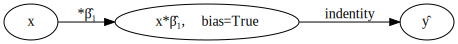

In [21]:
gv('''
"x" -> "x*β̂₁,    bias=True"[label="*β̂₁"] ;
"x*β̂₁,    bias=True" -> "ŷ"[label="indentity"] ''')


- 실제로는 이런식으로 많이 씀 

`-` 벡터로 표현하면 아래와 같음 

(표현3)

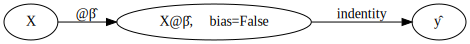

In [22]:
gv('''
"X" -> "X@β̂,    bias=False"[label="@β̂"] ;
"X@β̂,    bias=False" -> "ŷ"[label="indentity"] ''')


- 나는 이걸 좋아함 

`-` 딥러닝에서는 $\hat{\boldsymbol{\beta}}$ 을 $\hat{\bf W}$로 표현한다. 

(표현3)'

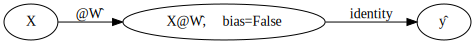

In [23]:
gv('''
"X" -> "X@Ŵ,    bias=False"[label="@Ŵ"] ;
"X@Ŵ,    bias=False" -> "ŷ"[label="identity"] ''')


`-` 실제로는 표현2 혹은 표현3을 외우면 된다. 

### Layer의 개념 

`-` (표현2) 혹은 (표현3) 의 과정은 레이어로 표현할 수 있다. 

`-` 레이어는 항상 아래와 같은 규칙을 가진다. (이게 사실 통계학의 GLM을 베낀거라고 생각해요)
- 첫 동그라미는 레이어의 입력이다. 
- 첫번째 화살표는 선형변환을 의미한다. 
- 두번째 동그라미는 선형변환의 결과이다. (이때 bias 가 false이냐 true 이냐에 따라서 실제수식이 조금 다름) 
- 두번째 화살표는 두번째 동그라미에 어떠한 함수 $f$를 취하는 것이다. (이 경우 $f(x)=x$) 
- 세번째 동그라미는 레이어의 최종출력이다. 

`-` 엄청 복잡해보이는데 결정할 것을 정리하면 아래와 같다. 
1. 레이어의 입력차원 
2. 선형변환 결과로 얻어지는 차원 
3. 선형변환에서 바이어스를 쓸지 안쓸지? 
4. 함수 $f$ 

`-` 주목: 1,2가 결정되면 자동으로 ${\bf \hat{W}}$의 차원이 결정된다. 

(예시)

- 입력차원2, 출력차원1: ${\bf W}$는 (2,1) 매트릭스 
- 입력차원20, 출력차원5: ${\bf W}$는 (20,5) 매트릭스 
- 입력차원2, 출력차원이50: ${\bf W}$는 (2,50) 매트릭스 

`-` 주목2: 이중에서 절대 생략불가능한 것은 "2. 선형변환 결과로 얻어지는 차원" 이다. 
- 레이어의 입력차원: 실제 레이어에 데이터가 들어올 때 데이터의 입력차원을 체크하여 스스로 알아낼 수 있다. 
- 바이어스를 쓸지 안 쓸지? 기본적으로 쓴다고 가정한다. 
- 함수 $f$: 기본적으로 항등함수를 가정한다. 

### Keras 를 이용한 풀이 

`-` 기본뼈대: net생성 $\to$ add(layer) $\to$ compile(opt,loss) $\to$ fit(data,epoch) 

`-` 데이터정리 

$${\bf y} \approx 2.5 + 4 {\bf x}$$

In [119]:
tnp.random.seed(43052)
N = 200
x = tnp.linspace(0,1,N) 
epsilon = tnp.random.randn(N)*0.5
y = 2.5+4*x + epsilon

In [120]:
X=tf.stack([tf.ones(N,dtype='float64'),x],axis=1)

#### 풀이1: 스칼라버전 

(0단계) 데이터정리 

In [231]:
y=y.reshape(-1)
x.shape, y.shape

(TensorShape([200]), TensorShape([200]))

(1단계) net생성 

In [232]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [233]:
layer = tf.keras.layers.Dense(1) 
# 입력차원 = 데이터 넣어보고 결정하겠음 
# 선형변환의 결과로 얻어치는 차원 = 1
# 바이어스 = 디폴트값을 쓰겠음 (use_bias=true) 
# 함수 = 디폴트값을 쓰겠음 (f(x)=x 를 쓴다는 의미) 

In [234]:
net.add(layer)

(3단계) net.compile(opt,loss) 

In [235]:
net.compile(tf.keras.optimizers.SGD(0.1), tf.losses.MSE) 

(4단계) fit(data,epoch) 

In [236]:
net.fit(x.reshape(N,1),y.reshape(N,1),epochs=1000,verbose=0,batch_size=N)  # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [237]:
net.weights

[<tf.Variable 'dense_38/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[3.9330251]], dtype=float32)>,
 <tf.Variable 'dense_38/bias:0' shape=(1,) dtype=float32, numpy=array([2.5836723], dtype=float32)>]

#### 풀이2: 벡터버전

(0단계) 데이터정리 

In [238]:
y=y.reshape(N,1)
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

(1단계) net생성 

In [239]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [240]:
layer = tf.keras.layers.Dense(1,use_bias=False)

In [241]:
net.add(layer)

(3단계) net.compile(opt,loss) 

In [242]:
net.compile(tf.keras.optimizers.SGD(0.1), tf.losses.MSE) 

(4단계) fit(data,epoch) 

In [243]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N) # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [244]:
net.weights

[<tf.Variable 'dense_39/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[2.5836723],
        [3.9330251]], dtype=float32)>]

#### 잠시문법정리 

`-` 잠깐 Dense layer 만드는 코드를 정리하자. 

(1) 아래는 모두 같은 코드이다. 

- tf.keras.layers.Dense(1) 
- tf.keras.layers.Dense(units=1) 
- tf.keras.layers.Dense(units=1,activation='linear') // identity가 더 맞는 표현 같은데 아무튼 linear라고 되어있음 
- tf.keras.layers.Dense(units=1,activation='linear',use_bias=True)

(2) 아래는 위와 살짝 다른 코드이다. 

- tf.keras.layers.Dense(1,input_dim=2) 
- tf.keras.layers.Dense(1,input_shape=(2,)) 

(3) 아래는 사용불가능한 코드이다. 
- tf.keras.layers.Dense(1,input_dim=(2,)) 
- tf.keras.layers.Dense(1,input_shape=2) 

`-` 왜 input_dim이 필요한가? 

In [ ]:
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Dense(1,use_bias=False))

In [ ]:
net2 = tf.keras.Sequential()
net2.add(tf.keras.layers.Dense(1,input_dim=2,use_bias=False))

In [226]:
net1.weights

ValueError: Weights for model sequential_28 have not yet been created. Weights are created when the Model is first called on inputs or `build()` is called with an `input_shape`.

In [227]:
net2.weights

[<tf.Variable 'dense_36/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[0.17441618],
        [0.30206478]], dtype=float32)>]

In [228]:
net1.summary()

ValueError: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.

In [229]:
net2.summary()

Model: "sequential_29"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


#### 풀이3: 스칼라버전, 임의의 초기값을 설정

(0단계) 데이터정리 

In [247]:
y=y.reshape(N,1)
x=x.reshape(N,1)
x.shape,y.shape

(TensorShape([200, 1]), TensorShape([200, 1]))

(1단계) net생성 

In [248]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [250]:
layer = tf.keras.layers.Dense(1,input_dim=1) 

In [251]:
net.add(layer)

---

초기값설정 

In [252]:
net.weights

[<tf.Variable 'dense_43/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[-0.32363296]], dtype=float32)>,
 <tf.Variable 'dense_43/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]

In [253]:
net.get_weights()

[array([[-0.32363296]], dtype=float32), array([0.], dtype=float32)]

In [254]:
net.set_weights?

Signature: net.set_weights(weights)
Docstring:
Sets the weights of the layer, from NumPy arrays.

The weights of a layer represent the state of the layer. This function
sets the weight values from numpy arrays. The weight values should be
passed in the order they are created by the layer. Note that the layer's
weights must be instantiated before calling this function, by calling
the layer.

For example, a `Dense` layer returns a list of two values: the kernel matrix
and the bias vector. These can be used to set the weights of another
`Dense` layer:

>>> layer_a = tf.keras.layers.Dense(1,
...   kernel_initializer=tf.constant_initializer(1.))
>>> a_out = layer_a(tf.convert_to_tensor([[1., 2., 3.]]))
>>> layer_a.get_weights()
[array([[1.],
       [1.],
       [1.]], dtype=float32), array([0.], dtype=float32)]
>>> layer_b = tf.keras.layers.Dense(1,
...   kernel_initializer=tf.constant_initializer(2.))
>>> b_out = layer_b(tf.convert_to_tensor([[10., 20., 30.]]))
>>> layer_b.get_weights()
[a

- layer_b.set_weights(layer_a.get_weights()) 와 같이 쓴다는 것이군? 

`-` net.get_weights()의 출력과 같은 방식으로 맞추자 

In [257]:
net.weights

[<tf.Variable 'dense_43/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[-0.32363296]], dtype=float32)>,
 <tf.Variable 'dense_43/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]

In [256]:
net.get_weights()

[array([[-0.32363296]], dtype=float32), array([0.], dtype=float32)]

In [259]:
[np.array([[10.0]],dtype=np.float32),np.array([-5],dtype=np.float32)]

[array([[10.]], dtype=float32), array([-5.], dtype=float32)]

In [260]:
net.set_weights([np.array([[10.0]],dtype=np.float32),np.array([-5],dtype=np.float32)])

In [261]:
net.weights

[<tf.Variable 'dense_43/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[10.]], dtype=float32)>,
 <tf.Variable 'dense_43/bias:0' shape=(1,) dtype=float32, numpy=array([-5.], dtype=float32)>]

---

(3단계) net.compile(opt,loss) 

In [262]:
net.compile(tf.keras.optimizers.SGD(0.1), tf.losses.MSE) 

(4단계) fit(data,epoch) 

In [263]:
net.fit(x.reshape(N,1),y.reshape(N,1),epochs=1000,verbose=0,batch_size=N)  # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [264]:
net.weights

[<tf.Variable 'dense_43/kernel:0' shape=(1, 1) dtype=float32, numpy=array([[3.933048]], dtype=float32)>,
 <tf.Variable 'dense_43/bias:0' shape=(1,) dtype=float32, numpy=array([2.58366], dtype=float32)>]

#### 풀이4: 벡터버전, 임의의 초기값을 설정 

(0단계) 데이터정리 

In [271]:
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

(1단계) net생성 

In [289]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [290]:
layer = tf.keras.layers.Dense(1,use_bias=False,input_dim=2)

In [291]:
net.add(layer)

(초기값설정) 

In [292]:
net.get_weights()

[array([[-0.18519735],
        [ 0.8297471 ]], dtype=float32)]

In [293]:
net.set_weights([np.array([[-5.0],[10.0]],dtype=np.float32)])

In [294]:
net.get_weights()

[array([[-5.],
        [10.]], dtype=float32)]

(3단계) net.compile(opt,loss) 

In [295]:
net.compile(tf.keras.optimizers.SGD(0.1), tf.losses.MSE) 

(4단계) fit(data,epoch) 

In [296]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N) # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [297]:
net.weights

[<tf.Variable 'dense_48/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[2.58366 ],
        [3.933048]], dtype=float32)>]

`-` 사실 실전에서는 초기값을 설정할 필요가 별로 없다. 

#### 풀이5: 벡터버전 사용자정의 손실함수 

(0단계) 데이터정리 

In [304]:
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

(1단계) net생성 

In [239]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [240]:
layer = tf.keras.layers.Dense(1,use_bias=False)

In [241]:
net.add(layer)

(3단계) net.compile(opt,loss) 

In [300]:
loss_fn = lambda y,yhat: (y-yhat).T @ (y-yhat)/ N
net.compile(tf.keras.optimizers.SGD(0.1), loss_fn) 

(4단계) fit(data,epoch) 

In [301]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N) # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [302]:
net.weights

[<tf.Variable 'dense_48/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[2.5836616],
        [3.9330447]], dtype=float32)>]

#### 풀이6: 벡터버전, net.compile의 옵션으로 손실함수 지정 

(0단계) 데이터정리 

In [303]:
X.shape, y.shape

(TensorShape([200, 2]), TensorShape([200, 1]))

(1단계) net생성 

In [305]:
net = tf.keras.Sequential()

(2단계) net.add(layer) 

In [306]:
layer = tf.keras.layers.Dense(1,use_bias=False)

In [307]:
net.add(layer)

(3단계) net.compile(opt,loss) 

In [308]:
net.compile(tf.keras.optimizers.SGD(0.1), loss='mse') 

(4단계) fit(data,epoch) 

In [309]:
net.fit(X,y,epochs=1000,verbose=0,batch_size=N) # batch_size=N 으로 해야 경사하강법이 적용, 그렇지 않으면 확률적 경사하강법 적용

결과확인

In [310]:
net.weights

[<tf.Variable 'dense_49/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[2.5836723],
        [3.9330251]], dtype=float32)>]